In [2]:
print("Hello World")

Hello World


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pandas as pd
from dateutil import parser
from sklearn.impute import KNNImputer


In [4]:
lunar = pd.read_csv("C:\Projects\eclipsed\Data\lunar.csv")
lunar.head()

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mukhe\AppData\Local\Temp\ipykernel_9740\1154566959.py:1: SyntaxWarning: invalid escape sequence '\P'
  lunar = pd.read_csv("C:\Projects\eclipsed\Data\lunar.csv")


,Catalog Number,Calendar Date,Eclipse Time,Delta T (s),Lunation Number,Saros Number,Eclipse Type,Quincena Solar Eclipse,Gamma,Penumbral Magnitude,Umbral Magnitude,Latitude,Longitude,Penumbral Eclipse Duration (m),Partial Eclipse Duration (m),Total Eclipse Duration (m)
0,1,-1999 June 26,14:13:28,46437,-49456,17,N,t-,-1.0981,0.8791,-0.1922,24S,22W,268.8,-,-
1,2,-1999 November 21,20:23:49,46427,-49451,-16,N,-a,-1.1155,0.8143,-0.1921,15N,98W,233.4,-,-
2,3,-1998 May 17,05:47:36,46416,-49445,-11,P,-t,0.8988,1.2105,0.2069,13S,89E,281.7,102.7,-
3,4,-1998 November 11,05:15:58,46404,-49439,-6,P,-a,-0.4644,2.0382,0.9740,12N,113E,343.4,200.8,-
4,5,-1997 May 6,18:57:01,46392,-49433,-1,T+,pp,0.1003,2.6513,1.6963,11S,92W,322.8,213.5,98.2


In [5]:
solar = pd.read_csv("C:\Projects\eclipsed\Data\solar.csv")
solar.head()

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mukhe\AppData\Local\Temp\ipykernel_9740\2919300919.py:1: SyntaxWarning: invalid escape sequence '\P'
  solar = pd.read_csv("C:\Projects\eclipsed\Data\solar.csv")


,Catalog Number,Calendar Date,Eclipse Time,Delta T (s),Lunation Number,Saros Number,Eclipse Type,Gamma,Eclipse Magnitude,Latitude,Longitude,Sun Altitude,Sun Azimuth,Path Width (km),Central Duration
0,1,-1999 June 12,03:14:51,46438,-49456,5,T,-0.2701,1.0733,6.0N,33.3W,74,344,247,06m37s
1,2,-1999 December 5,23:45:23,46426,-49450,10,A,-0.2317,0.9382,32.9S,10.8E,76,21,236,06m44s
2,3,-1998 June 1,18:09:16,46415,-49444,15,T,0.4994,1.0284,46.2N,83.4E,60,151,111,02m15s
3,4,-1998 November 25,05:57:03,46403,-49438,20,A,-0.9045,0.9806,67.8S,143.8W,25,74,162,01m14s
4,5,-1997 April 22,13:19:56,46393,-49433,-13,P,-1.4670,0.1611,60.6S,106.4W,0,281,NaN,NaN


In [6]:
print("--------------------------------SOLAR--------------------------------")
print(solar.info())
print(solar.isnull().sum())

print("--------------------------------LUNAR--------------------------------")
print(lunar.info())
print(lunar.isnull().sum())

--------------------------------SOLAR--------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11898 entries, 0 to 11897
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Catalog Number     11898 non-null  int64  
 1   Calendar Date      11898 non-null  object 
 2   Eclipse Time       11898 non-null  object 
 3   Delta T (s)        11898 non-null  int64  
 4   Lunation Number    11898 non-null  int64  
 5   Saros Number       11898 non-null  int64  
 6   Eclipse Type       11898 non-null  object 
 7   Gamma              11898 non-null  float64
 8   Eclipse Magnitude  11898 non-null  float64
 9   Latitude           11898 non-null  object 
 10  Longitude          11898 non-null  object 
 11  Sun Altitude       11898 non-null  int64  
 12  Sun Azimuth        11898 non-null  int64  
 13  Path Width (km)    7698 non-null   object 
 14  Central Duration   7698 non-null   object 
dtype

Note : Solar data contains missing values for features like 
Path Width (km)      4200
Central Duration     4200

In [7]:
print(solar.columns)
print(lunar.columns)

Index(['Catalog Number', 'Calendar Date', 'Eclipse Time', 'Delta T (s)',
       'Lunation Number', 'Saros Number', 'Eclipse Type', 'Gamma',
       'Eclipse Magnitude', 'Latitude', 'Longitude', 'Sun Altitude',
       'Sun Azimuth', 'Path Width (km)', 'Central Duration'],
      dtype='object')
Index(['Catalog Number', 'Calendar Date', 'Eclipse Time', 'Delta T (s)',
       'Lunation Number', 'Saros Number', 'Eclipse Type',
       'Quincena Solar Eclipse', 'Gamma', 'Penumbral Magnitude',
       'Umbral Magnitude', 'Latitude', 'Longitude',
       'Penumbral Eclipse Duration (m)', 'Partial Eclipse Duration (m)',
       'Total Eclipse Duration (m)'],
      dtype='object')


Manual Datetime Standardisation

In [8]:
# date time standerdization for AD years

# Dictionary to map month names to numbers
month_to_number = {
    'January': '01', 'February': '02', 'March': '03', 'April': '04',
    'May': '05', 'June': '06', 'July': '07', 'August': '08',
    'September': '09', 'October': '10', 'November': '11', 'December': '12'
}

# Function to manually parse and standardize dates
def manual_date_standardization(row):
    try:
        # Split the Calendar Date into parts
        parts = row['Calendar Date'].split()
        year = int(parts[0])  # First part is the year
        month = month_to_number[parts[1]]  # Map month name to number
        day = int(parts[2])  # Third part is the day
        
        # Construct the standardized date string
        standardized_date = f"{year:04d}-{month}-{day:02d}"
        
        # Append time if available
        if pd.notnull(row['Eclipse Time']):
            standardized_datetime = f"{standardized_date} {row['Eclipse Time']}"
        else:
            standardized_datetime = standardized_date
        
        return standardized_datetime
    except Exception as e:
        return None

# Apply the function to the AD dataframe
solar['Datetime'] = solar.apply(manual_date_standardization, axis=1)

# Display a few rows for verification
solar

,Catalog Number,Calendar Date,Eclipse Time,Delta T (s),Lunation Number,Saros Number,Eclipse Type,Gamma,Eclipse Magnitude,Latitude,Longitude,Sun Altitude,Sun Azimuth,Path Width (km),Central Duration,Datetime
0,1,-1999 June 12,03:14:51,46438,-49456,5,T,-0.2701,1.0733,6.0N,33.3W,74,344,247,06m37s,-1999-06-12 03:14:51
1,2,-1999 December 5,23:45:23,46426,-49450,10,A,-0.2317,0.9382,32.9S,10.8E,76,21,236,06m44s,-1999-12-05 23:45:23
2,3,-1998 June 1,18:09:16,46415,-49444,15,T,0.4994,1.0284,46.2N,83.4E,60,151,111,02m15s,-1998-06-01 18:09:16
3,4,-1998 November 25,05:57:03,46403,-49438,20,A,-0.9045,0.9806,67.8S,143.8W,25,74,162,01m14s,-1998-11-25 05:57:03
4,5,-1997 April 22,13:19:56,46393,-49433,-13,P,-1.4670,0.1611,60.6S,106.4W,0,281,NaN,NaN,-1997-04-22 13:19:56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11893,11894,2998 December 10,03:18:31,4414,12355,187,P,1.2838,0.4773,67.2N,145.0E,0,179,NaN,NaN,2998-12-10 03:18:31
11894,11895,2999 May 6,23:23:57,4417,12360,154,T,0.8388,1.0566,71.5N,177.3E,33,146,345,03m25s,2999-05-06 23:23:57
11895,11896,2999 October 30,09:34:33,4420,12366,159,A-,-1.0023,0.9586,70.9S,84.7W,0,137,-,-,2999-10-30 09:34:33
11896,11897,3000 April 26,14:18:06,4424,12372,164,T,0.1310,1.0222,21.1N,18.4W,82,166,76,02m11s,3000-04-26 14:18:06


Missing Values Handling 

In [9]:
# Check for missing values in the dataset
missing_values_summary = solar.isnull().sum()

# Filter columns with missing values
columns_with_missing = missing_values_summary[missing_values_summary > 0]

# Display columns with missing values and their counts
columns_with_missing

Path Width (km)     4200
Central Duration    4200
dtype: int64

In [10]:
df = solar
df.head(2)

,Catalog Number,Calendar Date,Eclipse Time,Delta T (s),Lunation Number,Saros Number,Eclipse Type,Gamma,Eclipse Magnitude,Latitude,Longitude,Sun Altitude,Sun Azimuth,Path Width (km),Central Duration,Datetime
0,1,-1999 June 12,03:14:51,46438,-49456,5,T,-0.2701,1.0733,6.0N,33.3W,74,344,247,06m37s,-1999-06-12 03:14:51
1,2,-1999 December 5,23:45:23,46426,-49450,10,A,-0.2317,0.9382,32.9S,10.8E,76,21,236,06m44s,-1999-12-05 23:45:23


In [11]:
solar["Path Width (km)"] = pd.to_numeric(solar["Path Width (km)"], errors='coerce')
solar['Path Width (km)'].fillna(solar['Path Width (km)'].median(), inplace=True)
solar.head()

C:\Users\mukhe\AppData\Local\Temp\ipykernel_9740\412213421.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  solar['Path Width (km)'].fillna(solar['Path Width (km)'].median(), inplace=True)


,Catalog Number,Calendar Date,Eclipse Time,Delta T (s),Lunation Number,Saros Number,Eclipse Type,Gamma,Eclipse Magnitude,Latitude,Longitude,Sun Altitude,Sun Azimuth,Path Width (km),Central Duration,Datetime
0,1,-1999 June 12,03:14:51,46438,-49456,5,T,-0.2701,1.0733,6.0N,33.3W,74,344,247.0,06m37s,-1999-06-12 03:14:51
1,2,-1999 December 5,23:45:23,46426,-49450,10,A,-0.2317,0.9382,32.9S,10.8E,76,21,236.0,06m44s,-1999-12-05 23:45:23
2,3,-1998 June 1,18:09:16,46415,-49444,15,T,0.4994,1.0284,46.2N,83.4E,60,151,111.0,02m15s,-1998-06-01 18:09:16
3,4,-1998 November 25,05:57:03,46403,-49438,20,A,-0.9045,0.9806,67.8S,143.8W,25,74,162.0,01m14s,-1998-11-25 05:57:03
4,5,-1997 April 22,13:19:56,46393,-49433,-13,P,-1.4670,0.1611,60.6S,106.4W,0,281,186.0,NaN,-1997-04-22 13:19:56


In [12]:
solar['Central Duration']

0        06m37s
1        06m44s
2        02m15s
3        01m14s
4           NaN
          ...  
11893       NaN
11894    03m25s
11895         -
11896    02m11s
11897    00m29s
Name: Central Duration, Length: 11898, dtype: object

In [13]:
# Function to convert 'MMmSSs' to seconds
def duration_to_seconds(duration):
    if pd.isna(duration):  # Handle NaN
        return np.nan
    try:
        minutes, seconds = map(int, duration.replace("m", " ").replace("s", "").split())
        return minutes * 60 + seconds
    except ValueError:
        return np.nan

# Apply the function to the column
solar["Central Duration (seconds)"] = solar["Central Duration"].apply(duration_to_seconds)
solar.head()

,Catalog Number,Calendar Date,Eclipse Time,Delta T (s),Lunation Number,Saros Number,Eclipse Type,Gamma,Eclipse Magnitude,Latitude,Longitude,Sun Altitude,Sun Azimuth,Path Width (km),Central Duration,Datetime,Central Duration (seconds)
0,1,-1999 June 12,03:14:51,46438,-49456,5,T,-0.2701,1.0733,6.0N,33.3W,74,344,247.0,06m37s,-1999-06-12 03:14:51,397.0
1,2,-1999 December 5,23:45:23,46426,-49450,10,A,-0.2317,0.9382,32.9S,10.8E,76,21,236.0,06m44s,-1999-12-05 23:45:23,404.0
2,3,-1998 June 1,18:09:16,46415,-49444,15,T,0.4994,1.0284,46.2N,83.4E,60,151,111.0,02m15s,-1998-06-01 18:09:16,135.0
3,4,-1998 November 25,05:57:03,46403,-49438,20,A,-0.9045,0.9806,67.8S,143.8W,25,74,162.0,01m14s,-1998-11-25 05:57:03,74.0
4,5,-1997 April 22,13:19:56,46393,-49433,-13,P,-1.4670,0.1611,60.6S,106.4W,0,281,186.0,NaN,-1997-04-22 13:19:56,NaN


In [14]:

imputer = KNNImputer(n_neighbors=5)
solar[["Path Width (km)", "Central Duration (seconds)"]] = imputer.fit_transform(
    solar[["Path Width (km)", "Central Duration (seconds)"]]
)
solar.head()

,Catalog Number,Calendar Date,Eclipse Time,Delta T (s),Lunation Number,Saros Number,Eclipse Type,Gamma,Eclipse Magnitude,Latitude,Longitude,Sun Altitude,Sun Azimuth,Path Width (km),Central Duration,Datetime,Central Duration (seconds)
0,1,-1999 June 12,03:14:51,46438,-49456,5,T,-0.2701,1.0733,6.0N,33.3W,74,344,247.0,06m37s,-1999-06-12 03:14:51,397.0
1,2,-1999 December 5,23:45:23,46426,-49450,10,A,-0.2317,0.9382,32.9S,10.8E,76,21,236.0,06m44s,-1999-12-05 23:45:23,404.0
2,3,-1998 June 1,18:09:16,46415,-49444,15,T,0.4994,1.0284,46.2N,83.4E,60,151,111.0,02m15s,-1998-06-01 18:09:16,135.0
3,4,-1998 November 25,05:57:03,46403,-49438,20,A,-0.9045,0.9806,67.8S,143.8W,25,74,162.0,01m14s,-1998-11-25 05:57:03,74.0
4,5,-1997 April 22,13:19:56,46393,-49433,-13,P,-1.4670,0.1611,60.6S,106.4W,0,281,186.0,NaN,-1997-04-22 13:19:56,169.6


In [15]:
solar.drop('Central Duration', axis = 1, inplace = True)
# Check for missing values in the dataset
missing_values_summary = solar.isnull().sum()

# Filter columns with missing values
columns_with_missing = missing_values_summary[missing_values_summary > 0]

# Display columns with missing values and their counts
columns_with_missing

Series([], dtype: int64)

Now, both dataframes are having 0 missing values

In [16]:
df.columns

Index(['Catalog Number', 'Calendar Date', 'Eclipse Time', 'Delta T (s)',
       'Lunation Number', 'Saros Number', 'Eclipse Type', 'Gamma',
       'Eclipse Magnitude', 'Latitude', 'Longitude', 'Sun Altitude',
       'Sun Azimuth', 'Path Width (km)', 'Datetime',
       'Central Duration (seconds)'],
      dtype='object')

In [17]:
columns = ['Delta T (s)',
       'Lunation Number', 'Saros Number', 'Gamma',
       'Eclipse Magnitude', 'Sun Altitude',
       'Sun Azimuth', 'Path Width (km)', 'Central Duration (seconds)']
for feature in columns:
    solar[feature] = pd.to_numeric(solar[feature], errors='coerce')

print(solar.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11898 entries, 0 to 11897
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Catalog Number              11898 non-null  int64  
 1   Calendar Date               11898 non-null  object 
 2   Eclipse Time                11898 non-null  object 
 3   Delta T (s)                 11898 non-null  int64  
 4   Lunation Number             11898 non-null  int64  
 5   Saros Number                11898 non-null  int64  
 6   Eclipse Type                11898 non-null  object 
 7   Gamma                       11898 non-null  float64
 8   Eclipse Magnitude           11898 non-null  float64
 9   Latitude                    11898 non-null  object 
 10  Longitude                   11898 non-null  object 
 11  Sun Altitude                11898 non-null  int64  
 12  Sun Azimuth                 11898 non-null  int64  
 13  Path Width (km)             118

Frequency Distribution of different numeric features

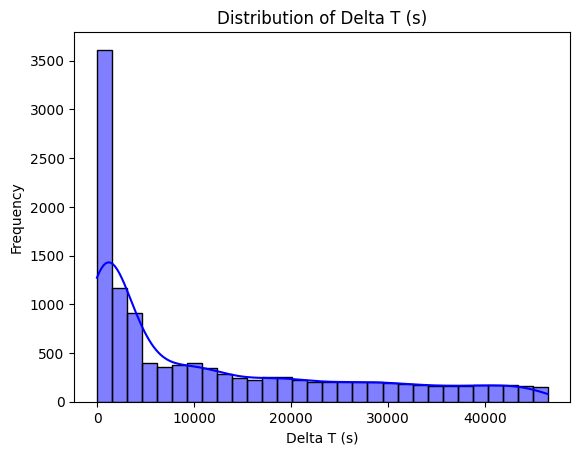

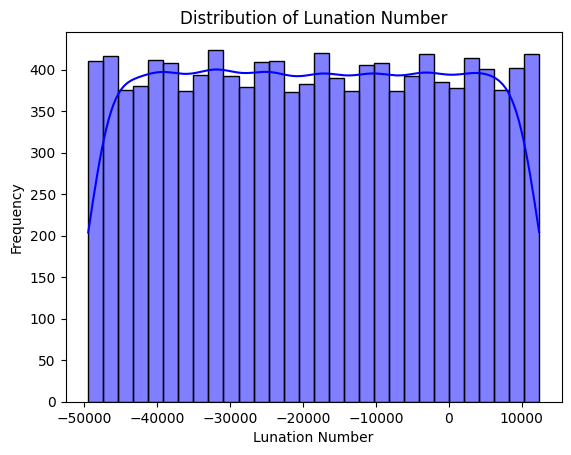

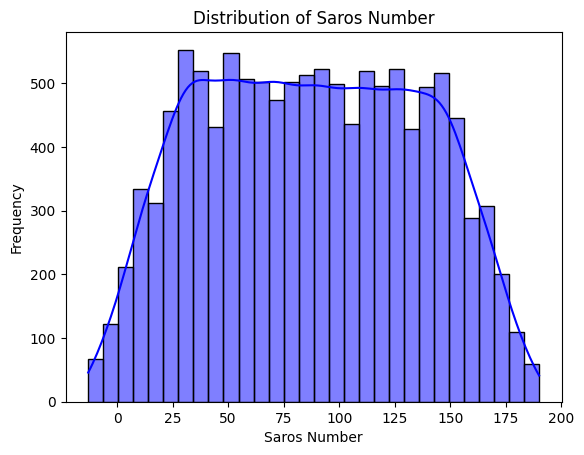

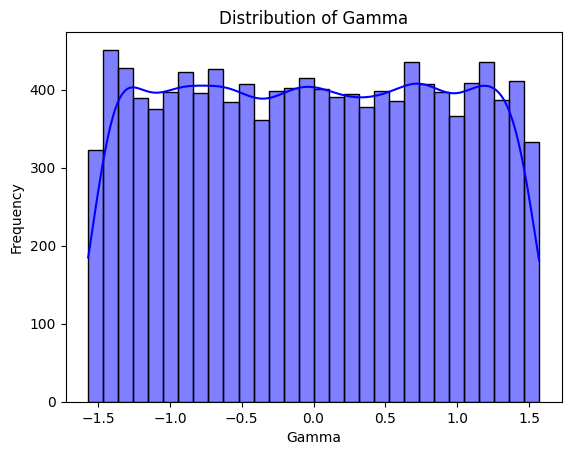

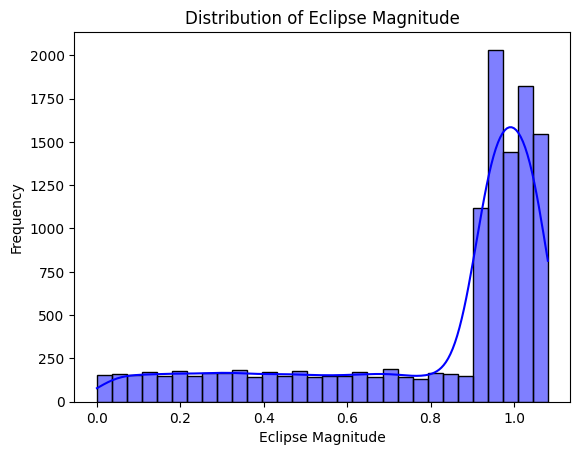

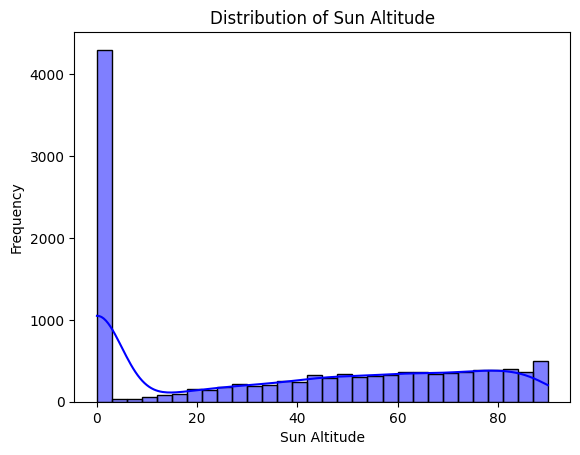

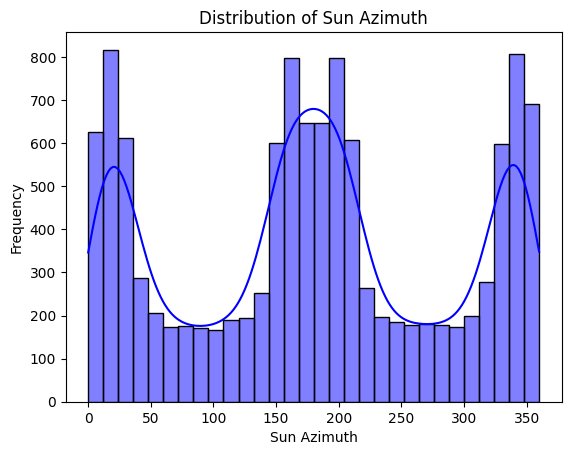

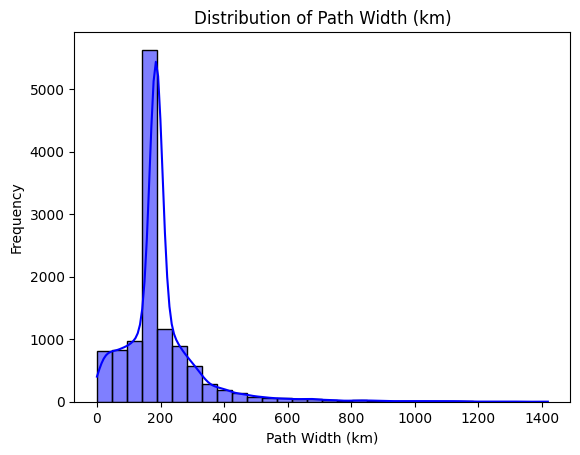

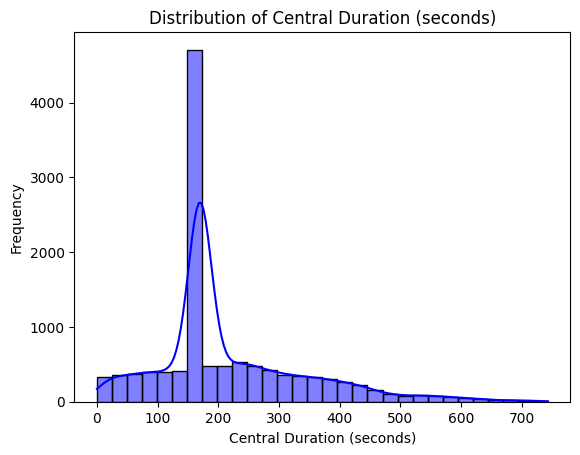

In [18]:
for column in columns:
    plt.figure()
    sns.histplot(solar[column], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

Seperating different units of time from the column Datetime in Solar dataset

In [19]:
solar['Year'] = solar['Datetime'].str[:5]
solar['Year'] = solar['Year'].str.rstrip('-')
solar['Year'] = solar['Year'].astype(int)

In [20]:
solar['Month'] = solar['Datetime'].str[5:8]
solar['Month'] = solar['Month'].str.strip('-')
solar['Month'] = solar['Month'].astype(int)

In [21]:
solar['Day'] = solar['Datetime'].str[8:11]
solar['Day'] = solar['Day'].str.strip('-')
solar['Day'] = solar['Day'].astype(int)

In [22]:
solar['Hour'] = solar['Datetime'].str[11:14]
solar['Hour'] = solar['Hour'].str.strip(':')
solar['Hour'] = solar['Hour'].astype(int)

In [23]:
solar['Minute'] = solar['Datetime'].str[14:17]
solar['Minute'] = solar['Minute'].str.strip(':')
solar['Minute'] = solar['Minute'].astype(int)

In [24]:
solar['Second'] = solar['Datetime'].str[17:]
solar['Second'] = solar['Second'].str.strip(':')
solar['Second'] = solar['Second'].astype(int)

In [25]:

solar.head(1)

,Catalog Number,Calendar Date,Eclipse Time,Delta T (s),Lunation Number,Saros Number,Eclipse Type,Gamma,Eclipse Magnitude,Latitude,...,Sun Azimuth,Path Width (km),Datetime,Central Duration (seconds),Year,Month,Day,Hour,Minute,Second
0,1,-1999 June 12,03:14:51,46438,-49456,5,T,-0.2701,1.0733,6.0N,...,344,247.0,-1999-06-12 03:14:51,397.0,-1999,6,12,3,14,51


In [26]:
solar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11898 entries, 0 to 11897
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Catalog Number              11898 non-null  int64  
 1   Calendar Date               11898 non-null  object 
 2   Eclipse Time                11898 non-null  object 
 3   Delta T (s)                 11898 non-null  int64  
 4   Lunation Number             11898 non-null  int64  
 5   Saros Number                11898 non-null  int64  
 6   Eclipse Type                11898 non-null  object 
 7   Gamma                       11898 non-null  float64
 8   Eclipse Magnitude           11898 non-null  float64
 9   Latitude                    11898 non-null  object 
 10  Longitude                   11898 non-null  object 
 11  Sun Altitude                11898 non-null  int64  
 12  Sun Azimuth                 11898 non-null  int64  
 13  Path Width (km)             118

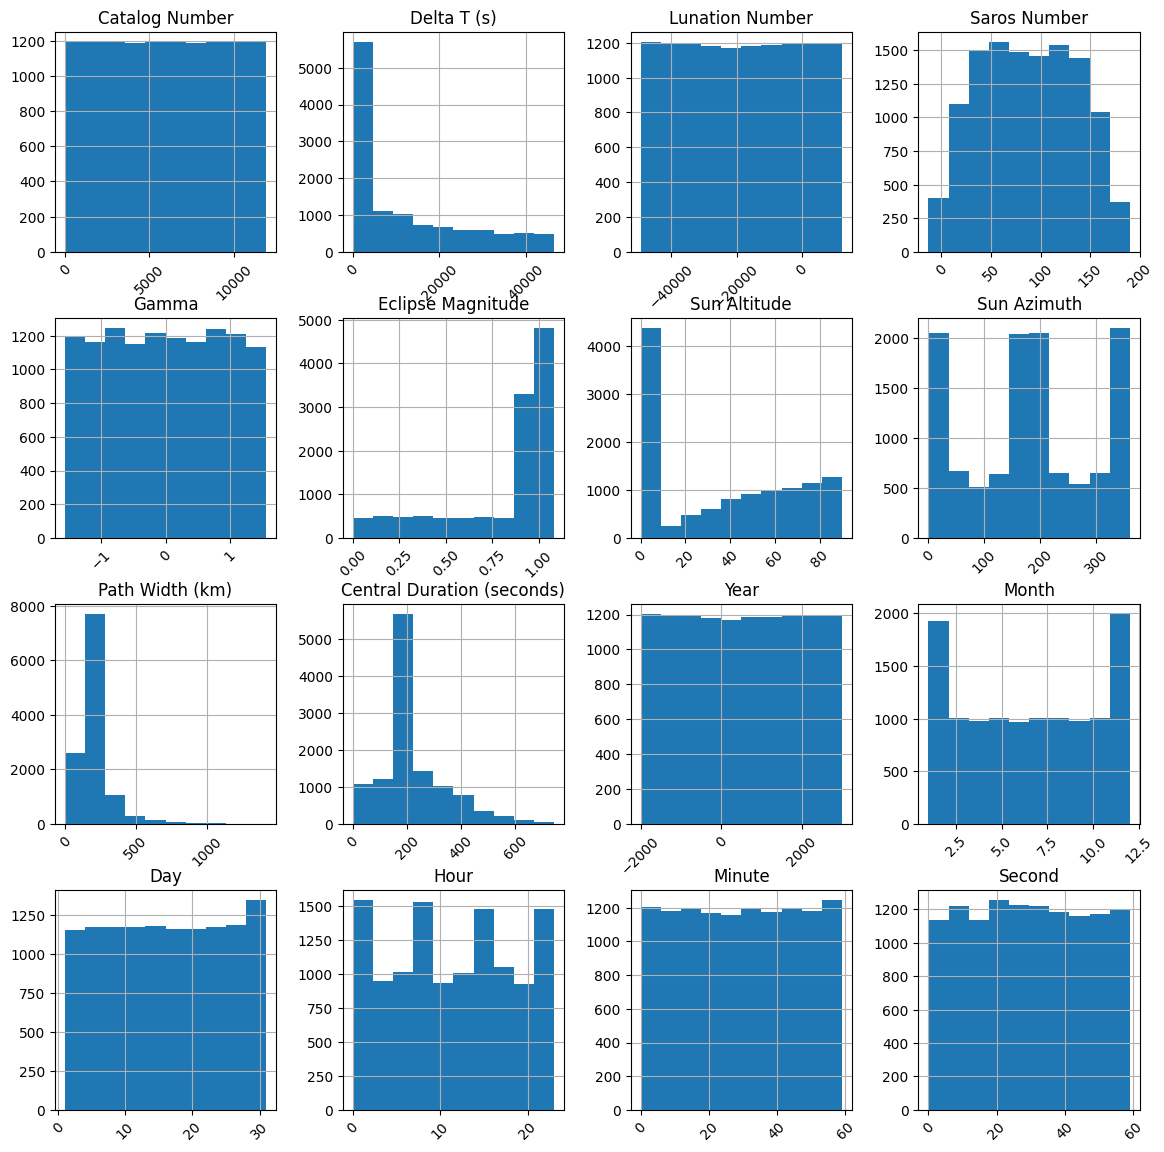

In [27]:
solar.hist(figsize=(14,14), xrot=45)
plt.show()

From this set of Histogram plots of numericals features, we can notice that

1. Uniform distribution in Gamma, Lunation Number & all other time related features.

2. Delta T (s): The distribution is highly skewed to the right, indicating that most values are small, but some extreme values exist.

3. Saros Number: This follows a normal-like distribution, peaking around the middle range. This suggests that most eclipses occur within a certain Saros cycle range.

4. Delta T (s): The distribution is highly skewed to the right, indicating that most values are small, but some extreme values exist.

5. Eclipse Magnitude: Shows a strong peak at 1.0, indicating that many eclipses are total or annular.

6. Sun Altitude: Increases towards higher values, meaning most observed eclipses occur at higher solar altitudes.

7. Sun Azimuth: Displays a bimodal distribution, suggesting preferred azimuth angles at which eclipses are more frequently observed.

8. Path Width (km): Skewed distribution with most values at the lower end, suggesting that the majority of eclipses have smaller path widths.

9. Central Duration (seconds): Shows a peak at lower values, indicating that most eclipses have short total durations.

In [ ]:
def convert_lat_long(value):
    """
    Converts a latitude or longitude string with directional indicators (N, S, E, W)
    to a signed decimal degree. (e.g. '37.7749N' -> 37.7749, '122.4194W' -> -122.4194)
    """
    if isinstance(value, str):
        # Extract numeric part and direction
        numeric_value = float(value[:-1])  # Remove the last character (direction)
        direction = value[-1].upper()     # Get the last character (N, S, E, W)
        # Adjust sign based on direction
        if direction in ["S", "W"]:
            numeric_value = -numeric_value
        return numeric_value
    raise ValueError("Invalid format for latitude or longitude")

# Apply the conversion to the Latitude column
solar["Latitude"] = solar["Latitude"].apply(convert_lat_long)
solar["Longitude"] = solar["Longitude"].apply(convert_lat_long)
solar.head(2)

,Catalog Number,Calendar Date,Eclipse Time,Delta T (s),Lunation Number,Saros Number,Eclipse Type,Gamma,Eclipse Magnitude,Latitude,...,Sun Azimuth,Path Width (km),Datetime,Central Duration (seconds),Year,Month,Day,Hour,Minute,Second
0,1,-1999 June 12,03:14:51,46438,-49456,5,T,-0.2701,1.0733,6.0,...,344,247.0,-1999-06-12 03:14:51,397.0,-1999,6,12,3,14,51
1,2,-1999 December 5,23:45:23,46426,-49450,10,A,-0.2317,0.9382,-32.9,...,21,236.0,-1999-12-05 23:45:23,404.0,-1999,12,5,23,45,23


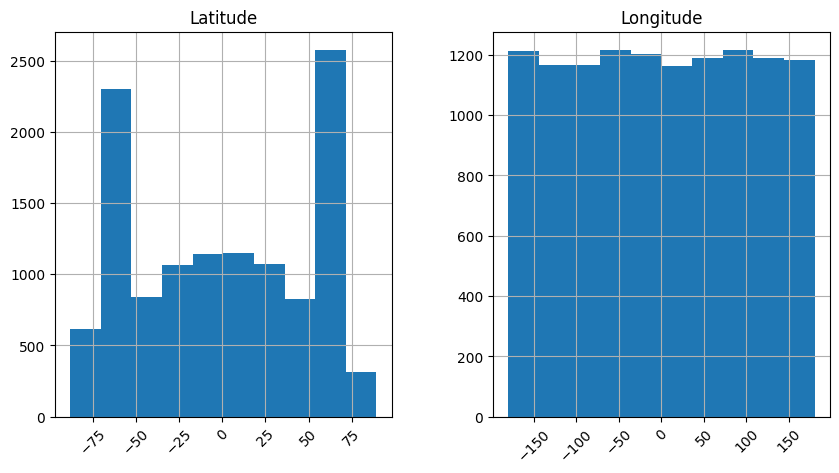

In [32]:
lat_lon = solar[['Latitude', 'Longitude']]
lat_lon.hist(figsize=(10,5), xrot=45)
plt.show()

In [33]:
solar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11898 entries, 0 to 11897
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Catalog Number              11898 non-null  int64  
 1   Calendar Date               11898 non-null  object 
 2   Eclipse Time                11898 non-null  object 
 3   Delta T (s)                 11898 non-null  int64  
 4   Lunation Number             11898 non-null  int64  
 5   Saros Number                11898 non-null  int64  
 6   Eclipse Type                11898 non-null  object 
 7   Gamma                       11898 non-null  float64
 8   Eclipse Magnitude           11898 non-null  float64
 9   Latitude                    11898 non-null  float64
 10  Longitude                   11898 non-null  float64
 11  Sun Altitude                11898 non-null  int64  
 12  Sun Azimuth                 11898 non-null  int64  
 13  Path Width (km)             118

HeatMap to find out strong correlation between the features 

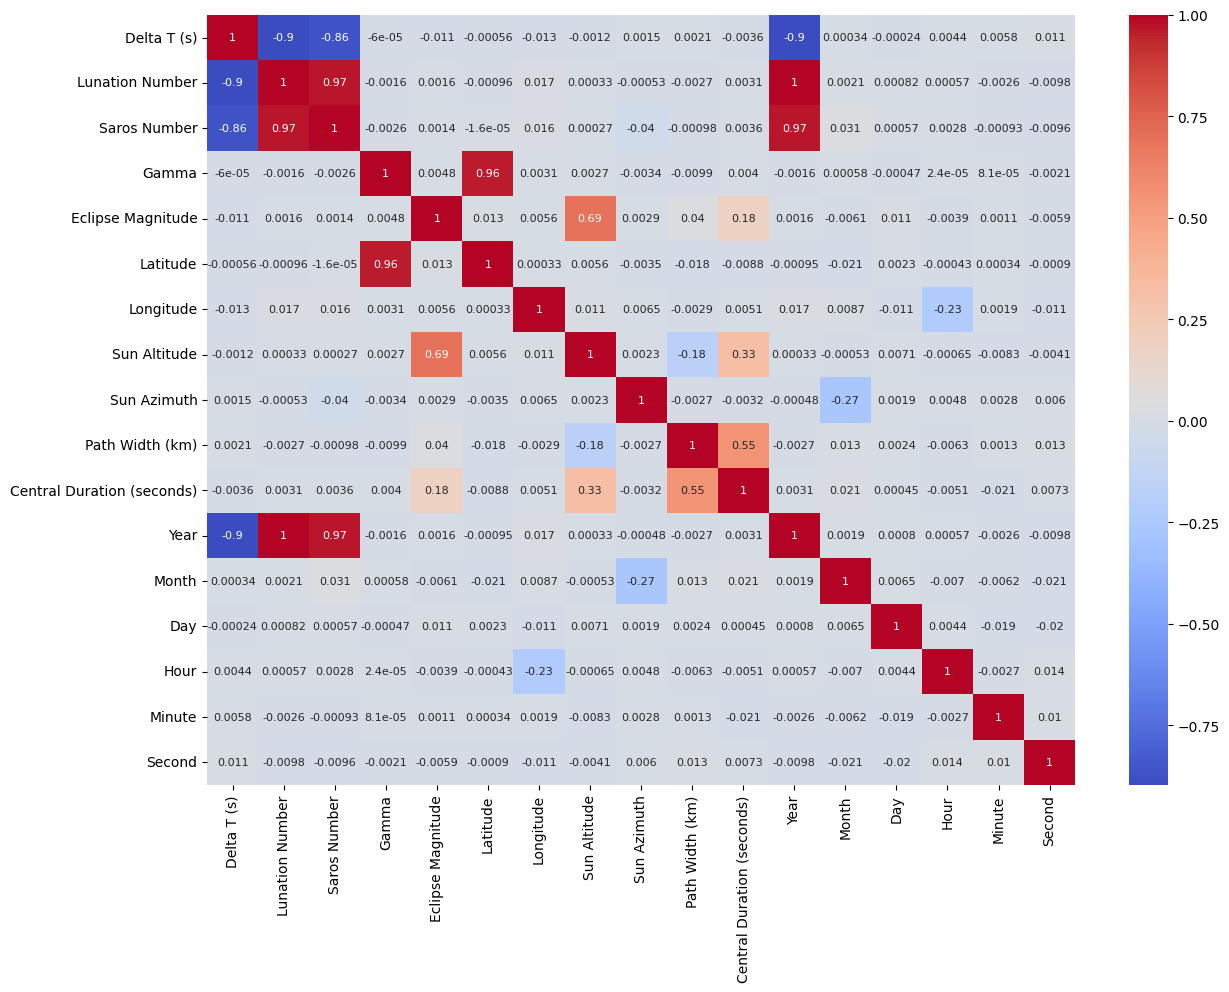

In [40]:
# Selecting only numeric columns
numeric_solar = solar.select_dtypes(include=["number"])
numeric_solar.drop("Catalog Number", axis=1, inplace=True)

# Plotting the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_solar.corr(), annot=True, cmap="coolwarm", annot_kws={"size": 8})
plt.show()

Key observations are

-> Eclipse periodicity is well reflected in the correlation of Lunation & Saros numbers.

-> Latitude plays a major role in determining eclipse magnitude.

-> Eclipse duration is moderately correlated with the width of the eclipse path.

-> Some weak dependencies exist between month, time, and eclipse properties.